In [16]:
# --- Task 2 Libraries ---
import pandas as pd
import numpy as np

from textblob import TextBlob
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

import re
import string

nltk.download('punkt')
nltk.download('stopwords')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
from google.colab import files
uploaded = files.upload()


Saving combined_cleaned_reviews.csv to combined_cleaned_reviews (1).csv


In [18]:
import pandas as pd

df = pd.read_csv("combined_cleaned_reviews.csv", parse_dates=['review_date'])
df.head()


,review_text,rating,review_date,bank,source,app_package
0,🙏👍,5,2025-11-29,BOA,Google Play,com.boa.boaMobileBanking
1,Very Good,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking
2,goof,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking
3,good!,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking
4,good jop,5,2025-11-27,BOA,Google Play,com.boa.boaMobileBanking


In [19]:
import re

df = df.dropna(subset=['review_text'])

def clean_text(x):
    x = str(x)
    x = x.lower()
    x = re.sub(r'[^a-zA-Z0-9\s]', ' ', x)
    x = re.sub(r'\s+', ' ', x)
    return x.strip()

df['clean_text'] = df['review_text'].apply(clean_text)

df.head()


,review_text,rating,review_date,bank,source,app_package,clean_text
0,🙏👍,5,2025-11-29,BOA,Google Play,com.boa.boaMobileBanking,
1,Very Good,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,very good
2,goof,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,goof
3,good!,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,good
4,good jop,5,2025-11-27,BOA,Google Play,com.boa.boaMobileBanking,good jop


In [20]:
!pip install transformers torch --quiet
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis")

sent_results = sentiment_model(
    df["clean_text"].tolist(),
    truncation=True
)

df["sentiment_label"] = [r["label"] for r in sent_results]
df["sentiment_score"] = [r["score"] for r in sent_results]

df.head()


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cpu


,review_text,rating,review_date,bank,source,app_package,clean_text,sentiment_label,sentiment_score
0,🙏👍,5,2025-11-29,BOA,Google Play,com.boa.boaMobileBanking,,POSITIVE,0.748121
1,Very Good,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,very good,POSITIVE,0.999852
2,goof,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,goof,NEGATIVE,0.997528
3,good!,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,good,POSITIVE,0.999816
4,good jop,5,2025-11-27,BOA,Google Play,com.boa.boaMobileBanking,good jop,POSITIVE,0.999841


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=50,
    stop_words="english",
    ngram_range=(1, 2)
)

X = vectorizer.fit_transform(df["clean_text"])
keywords = vectorizer.get_feature_names_out()

keywords[:40]


array(['account', 'amole', 'app', 'application', 'apps', 'bad', 'bank',
       'banking', 'banking app', 'best', 'best app', 'boa', 'cbe',
       'dashen', 'dashen bank', 'developer', 'does', 'doesn',
       'doesn work', 'don', 'easy', 'ethiopia', 'fast', 'fix', 'good',
       'good app', 'great', 'just', 'like', 'make', 'mobile',
       'mobile banking', 'money', 'need', 'nice', 'open', 'options',
       'phone', 'problem', 'service'], dtype=object)

In [22]:
def detect_theme(text):
    text = text.lower()

    if any(word in text for word in ["slow", "loading", "lag", "delay"]):
        return "Performance"
    if any(word in text for word in ["login", "password", "otp"]):
        return "Login/Access"
    if any(word in text for word in ["crash", "freeze", "bug", "error"]):
        return "Crashes/Bugs"
    if any(word in text for word in ["ui", "interface", "design", "feature"]):
        return "Features/UI"
    if any(word in text for word in ["support", "help", "service"]):
        return "Support"

    return "Other"

df["theme"] = df["clean_text"].apply(detect_theme)

df.head(15)


,review_text,rating,review_date,bank,source,app_package,clean_text,sentiment_label,sentiment_score,theme
0,🙏👍,5,2025-11-29,BOA,Google Play,com.boa.boaMobileBanking,,POSITIVE,0.748121,Other
1,Very Good,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,very good,POSITIVE,0.999852,Other
2,goof,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,goof,NEGATIVE,0.997528,Other
3,good!,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,good,POSITIVE,0.999816,Other
4,good jop,5,2025-11-27,BOA,Google Play,com.boa.boaMobileBanking,good jop,POSITIVE,0.999841,Other
5,bad exprience...it is so crushed,1,2025-11-27,BOA,Google Play,com.boa.boaMobileBanking,bad exprience it is so crushed,NEGATIVE,0.999739,Other
6,not user friendly at all it requires a huge co...,1,2025-11-26,BOA,Google Play,com.boa.boaMobileBanking,not user friendly at all it requires a huge co...,NEGATIVE,0.999757,Performance
7,ምንም የማይ ሰራ,1,2025-11-26,BOA,Google Play,com.boa.boaMobileBanking,,POSITIVE,0.748121,Other
8,very good,5,2025-11-25,BOA,Google Play,com.boa.boaMobileBanking,very good,POSITIVE,0.999852,Other
9,most of the time is not working properly,1,2025-11-25,BOA,Google Play,com.boa.boaMobileBanking,most of the time is not working properly,NEGATIVE,0.999764,Other


In [23]:
df.to_csv("task2_sentiment_and_themes.csv", index=False)
df.head()


,review_text,rating,review_date,bank,source,app_package,clean_text,sentiment_label,sentiment_score,theme
0,🙏👍,5,2025-11-29,BOA,Google Play,com.boa.boaMobileBanking,,POSITIVE,0.748121,Other
1,Very Good,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,very good,POSITIVE,0.999852,Other
2,goof,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,goof,NEGATIVE,0.997528,Other
3,good!,5,2025-11-28,BOA,Google Play,com.boa.boaMobileBanking,good,POSITIVE,0.999816,Other
4,good jop,5,2025-11-27,BOA,Google Play,com.boa.boaMobileBanking,good jop,POSITIVE,0.999841,Other


In [24]:
import pandas as pd

# Load CSV
df = pd.read_csv("task2_sentiment_and_themes.csv")

# Check columns
print(df.columns)


Index(['review_text', 'rating', 'review_date', 'bank', 'source', 'app_package',
       'clean_text', 'sentiment_label', 'sentiment_score', 'theme'],
      dtype='object')


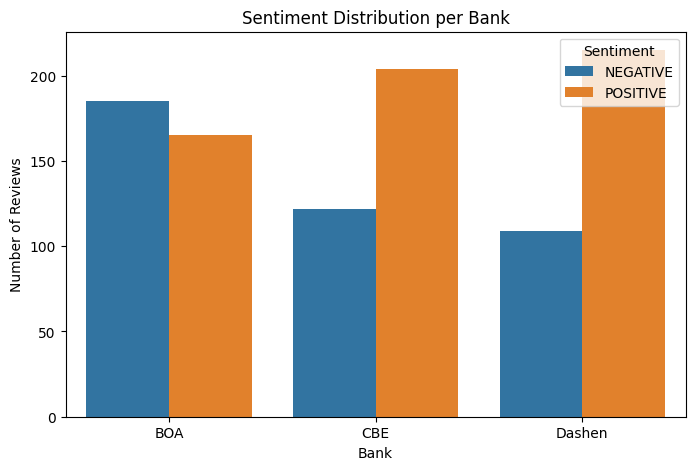

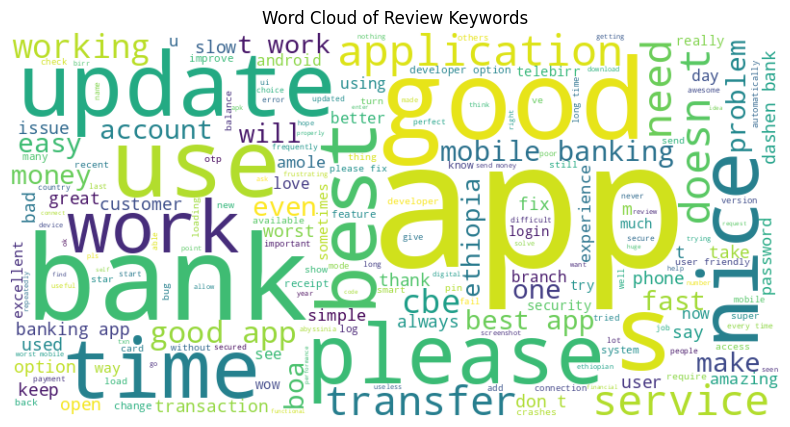

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Load CSV
df = pd.read_csv("task2_sentiment_and_themes.csv")

# -------------------------------
# 1. Sentiment Distribution Bar Chart
# -------------------------------
sentiment_counts = df.groupby(['bank', 'sentiment_label']).size().reset_index(name='count')

plt.figure(figsize=(8,5))
sns.barplot(data=sentiment_counts, x='bank', y='count', hue='sentiment_label')
plt.title('Sentiment Distribution per Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')
plt.legend(title='Sentiment')
plt.show()

# -------------------------------
# 2. Word Cloud for Keywords
# -------------------------------
text = " ".join(df['clean_text'].dropna())  # combine all cleaned reviews

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Review Keywords')
plt.show()


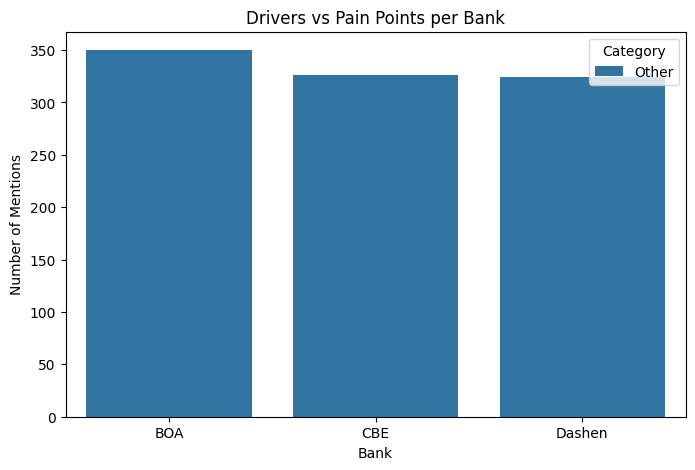

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load your CSV
df = pd.read_csv("task2_sentiment_and_themes.csv")

# Example: categorize themes into Driver vs Pain Point
drivers = ['Fast navigation', 'Easy login', 'Fingerprint login']
pain_points = ['Slow transfers', 'App crashes', 'UI glitches']

def categorize_theme(theme):
    if theme in drivers:
        return 'Driver'
    elif theme in pain_points:
        return 'Pain Point'
    else:
        return 'Other'

df['category'] = df['theme'].apply(categorize_theme)

# Count per bank
category_counts = df.groupby(['bank', 'category']).size().reset_index(name='count')

# Plot
plt.figure(figsize=(8,5))
sns.barplot(data=category_counts, x='bank', y='count', hue='category')
plt.title('Drivers vs Pain Points per Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Mentions')
plt.legend(title='Category')
plt.show()


In [28]:
df.to_csv("task2_output.csv", index=False)


In [29]:
from google.colab import files
files.download("task2_output.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>